# Human Coding and Feasibility Gate (Notebook 04)

This notebook is the **reproducible evidence** for the feasibility gate. It reads
the completed, hand-coded review sample (the annotator's workbook), validates it,
and computes — from the file, not by hand — the numbers that decide whether the
paper keeps *contestation* as its central construct or widens to *epistemic
friction*, plus the taxonomy distributions that feed the Findings.

Inputs: the coded `*_CODING.xlsx` produced by the annotator (Notebook 02 built the
blank sample; the human filled it).
Outputs: validated gold labels (`feasibility_review_sample_HUMAN.csv`), gate and
taxonomy tables under `outputs/04_human_coding_and_gate/`, a `gate_summary.json`,
and a printed verdict.

In [1]:
# ============================================================
# 1. Config, paths, controlled vocabulary
# ============================================================
from __future__ import annotations
import json, logging, re
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import display
try:
    import matplotlib.pyplot as plt
    _HAVE_MPL = True
except Exception:  # noqa: BLE001
    _HAVE_MPL = False

logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")
LOGGER = logging.getLogger("xai_contestation")

def find_project_root(start=None):
    start = (Path.cwd() if start is None else Path(start)).resolve()
    for c in [start, *start.parents]:
        if (c / "data").is_dir():
            return c
    raise FileNotFoundError("Could not locate the project root (a parent with data/).")

PROJECT_ROOT = find_project_root()
TABLES_IN = PROJECT_ROOT / "outputs" / "02_translation_and_feasibility_audit" / "tables"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "04_human_coding_and_gate"
TABLE_OUT = OUTPUT_DIR / "tables"; FIG_OUT = OUTPUT_DIR / "figures"
for d in (TABLE_OUT, FIG_OUT): d.mkdir(parents=True, exist_ok=True)

# The completed workbook. Override CODED_FILE if you renamed it; otherwise the
# most recently modified *CODING*.xlsx in the tables folder is used.
CODED_FILE = TABLES_IN / "feasibility_review_sample_claude_translated_CODING.xlsx"
if not CODED_FILE.exists():
    cands = [p for p in TABLES_IN.glob("*CODING*.xlsx") if not p.name.startswith("~$")]
    if not cands:
        raise FileNotFoundError(f"No coded *CODING*.xlsx found in {TABLES_IN}")
    CODED_FILE = max(cands, key=lambda p: p.stat().st_mtime)
LOGGER.info("Reading coded workbook: %s", CODED_FILE.name)

VOCAB = {
    "is_contestation": ["yes", "no"],
    "presence": ["explicit", "implicit", "ambiguous", "absent"],
    "target": ["prediction", "reasoning", "evidence", "input data",
               "explanation representation", "system competence", "n/a"],
    "interaction_act": ["request for justification", "direct challenge", "correction",
                        "alternative proposal", "counterexample", "rejection",
                        "request to acknowledge uncertainty", "n/a"],
    "grounds": ["domain knowledge", "technical knowledge", "prior experience",
                "internal inconsistency", "missing evidence", "data-quality concern",
                "causal implausibility", "presentation ambiguity", "n/a"],
    "expected_response": ["justify", "revise", "incorporate correction",
                          "provide additional information", "acknowledge uncertainty",
                          "expose conflicting evidence", "defer to human expertise", "n/a"],
}
DIMS = list(VOCAB)
STRUCT = ["target", "interaction_act", "grounds", "expected_response"]

INFO | Reading coded workbook: feasibility_review_sample_claude_translated_CODING.xlsx


In [2]:
# ============================================================
# 2. Load the coded workbook and normalise label values
# ============================================================
raw = pd.read_excel(CODED_FILE, sheet_name="Coding", engine="openpyxl")

def norm(v):
    if v is None or (isinstance(v, float) and np.isnan(v)):
        return pd.NA
    s = re.sub(r"\s+", " ", str(v).strip().lower())
    return pd.NA if s in ("", "nan") else s

coded = raw.copy()
for c in DIMS:
    if c not in coded.columns:
        raise KeyError(f"Column '{c}' missing from the coded sheet.")
    coded[c] = coded[c].map(norm)

LOGGER.info("Loaded %d coded rows.", len(coded))
display(coded[["__utt_id", "participant_group", "explanation_format",
               "speaker", "is_contestation"] + STRUCT].head(6))

INFO | Loaded 88 coded rows.


,__utt_id,participant_group,explanation_format,speaker,is_contestation,target,interaction_act,grounds,expected_response
0,DR_SSH_07:459,SSH,LIME,Participant,no,NaN,NaN,NaN,NaN
1,PK_DE_01:207,DE,Anchor,Interviewer,yes,reasoning,alternative proposal,domain knowledge,revise
2,PK_DE_05:105,DE,SHAP,Participant,yes,explanation representation,alternative proposal,presentation ambiguity,incorporate correction
3,PK_DE_04:162,DE,LIME,Participant,yes,evidence,request for justification,missing evidence,provide additional information
4,PK_DE_01:190,DE,Descriptive statistics,Interviewer,no,NaN,NaN,NaN,NaN
5,MZ_SSH_04:169,SSH,Counterfactual,Participant,no,NaN,NaN,NaN,NaN


In [3]:
# ============================================================
# 3. Validation (fail loudly if the coding is inconsistent)
# ============================================================
report = {}
report["rows"] = int(len(coded))
report["is_contestation_filled"] = int(coded["is_contestation"].notna().sum())

# (a) every value must be in its controlled vocabulary
offvocab = {}
for c in DIMS:
    allowed = set(VOCAB[c])
    bad = sorted({v for v in coded[c].dropna() if v not in allowed})
    if bad:
        offvocab[c] = bad
report["off_vocabulary"] = offvocab

# (b) n/a consistency
is_c = coded["is_contestation"]
no = coded[is_c == "no"]
yes = coded[is_c == "yes"]
# A 'no' row is fine if its structure fields are blank OR the literal 'n/a',
# and presence is blank OR 'absent'. It is only wrong if it carries a *real*
# category (i.e. the coder marked a target/act/etc. on a non-contestation row).
bad_no = no[(no["presence"].notna() & (no["presence"] != "absent"))
           | no[STRUCT].apply(lambda r: any(pd.notna(r[c]) and r[c] != "n/a"
                                             for c in STRUCT), axis=1)]
bad_yes = yes[yes["presence"].isna() | (yes["presence"] == "absent")
             | yes[STRUCT].apply(lambda r: any(pd.isna(r[c]) or r[c] == "n/a"
                                               for c in STRUCT), axis=1)]
report["no_rows_with_bad_structure"] = bad_no["__utt_id"].tolist()
report["yes_rows_incomplete"] = bad_yes["__utt_id"].tolist()

print("Validation")
print("  rows:", report["rows"], "| is_contestation filled:", report["is_contestation_filled"])
print("  off-vocabulary values:", offvocab if offvocab else "none")
print("  'no' rows with non-absent / non-n/a fields:", len(bad_no))
print("  'yes' rows missing a taxonomy field:", len(bad_yes))
if len(bad_yes):
    display(bad_yes[["__utt_id", "participant_group", "explanation_format"] + ["presence"] + STRUCT])

clean = (report["is_contestation_filled"] == report["rows"]
         and not offvocab and not len(bad_no) and not len(bad_yes))
if clean:
    LOGGER.info("Coding is complete and internally consistent.")
else:
    LOGGER.warning("Coding has issues above; fix them in the workbook, save, and re-run.")

INFO | Coding is complete and internally consistent.


Validation
  rows: 88 | is_contestation filled: 88
  off-vocabulary values: none
  'no' rows with non-absent / non-n/a fields: 0
  'yes' rows missing a taxonomy field: 0


total episodes:            88
contestation = yes:        47  (53%)   <- lexical-filter precision
contestation = no:         41  (47%)
groups represented (yes):  3 / 3
formats represented (yes): 5 / 5

Confirmed contestation by participant group x explanation format:


explanation_format,Descriptive statistics,SHAP,LIME,Anchor,Counterfactual,Total
participant_group,,,,,,
DE,4,2,3,4,4,17
IT,5,2,2,1,3,13
SSH,4,5,1,3,4,17


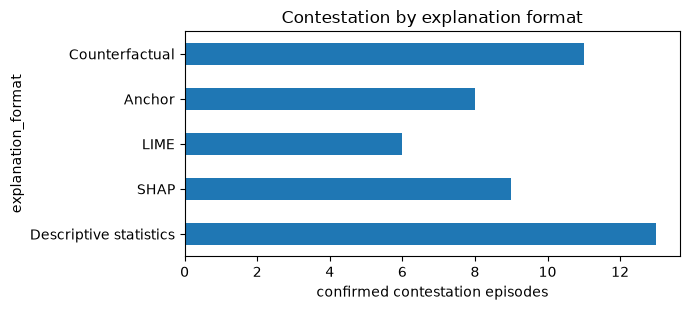

In [4]:
# ============================================================
# 4. Feasibility gate: filter precision + diversity
# ============================================================
n = len(coded); n_yes = int((is_c == "yes").sum()); n_no = int((is_c == "no").sum())
precision = n_yes / n if n else float("nan")

groups_all = sorted(coded["participant_group"].dropna().unique())
formats_all = [f for f in ["Descriptive statistics", "SHAP", "LIME", "Anchor",
                           "Counterfactual"] if f in set(coded["explanation_format"])]
grp_cov = yes["participant_group"].nunique()
fmt_cov = yes["explanation_format"].nunique()

gxf = (pd.crosstab(yes["participant_group"], yes["explanation_format"])
       .reindex(index=groups_all, columns=formats_all, fill_value=0))

print(f"total episodes:            {n}")
print(f"contestation = yes:        {n_yes}  ({precision:.0%})   <- lexical-filter precision")
print(f"contestation = no:         {n_no}  ({n_no/n:.0%})")
print(f"groups represented (yes):  {grp_cov} / {len(groups_all)}")
print(f"formats represented (yes): {fmt_cov} / {len(formats_all)}")
print("\nConfirmed contestation by participant group x explanation format:")
display(gxf.assign(Total=gxf.sum(axis=1)))
gxf.to_csv(TABLE_OUT / "confirmed_contestation_group_by_format.csv")

if _HAVE_MPL:
    ax = gxf.sum(axis=0).reindex(formats_all).plot(kind="barh", figsize=(7, 3.2))
    ax.set_xlabel("confirmed contestation episodes"); ax.set_title("Contestation by explanation format")
    plt.tight_layout(); plt.savefig(FIG_OUT / "contestation_by_format.png", dpi=150); plt.show()

In [5]:
# ============================================================
# 5. Taxonomy distributions (only the confirmed 'yes' episodes)
# ============================================================
def dist(col):
    s = (yes[col].dropna())
    s = s[s != "n/a"]
    return s.value_counts()

tax_tables = {}
for c in ["presence", "target", "interaction_act", "grounds", "expected_response"]:
    vc = dist(c).rename("episodes")
    tax_tables[c] = vc
    print(f"\n{c}  (of {n_yes} contestation episodes)")
    display(vc.to_frame())
    vc.to_frame().to_csv(TABLE_OUT / f"dist_{c}.csv")

# every dimension should have >1 category instantiated for the taxonomy to hold
dims_populated = {c: int(dist(c).shape[0]) for c in
                  ["target", "interaction_act", "grounds", "expected_response"]}
print("\ncategories instantiated per dimension:", dims_populated)


presence  (of 47 contestation episodes)


,episodes
presence,
implicit,18
ambiguous,15
explicit,14



target  (of 47 contestation episodes)


,episodes
target,
explanation representation,17
evidence,9
input data,8
reasoning,6
system competence,4
prediction,3



interaction_act  (of 47 contestation episodes)


...


grounds  (of 47 contestation episodes)


,episodes
grounds,
domain knowledge,11
missing evidence,9
presentation ambiguity,8
technical knowledge,8
data-quality concern,5
prior experience,3
causal implausibility,2
internal inconsistency,1



expected_response  (of 47 contestation episodes)


,episodes
expected_response,
justify,14
provide additional information,11
incorporate correction,10
revise,5
defer to human expertise,3
acknowledge uncertainty,2
expose conflicting evidence,2



categories instantiated per dimension: {'target': 6, 'interaction_act': 7, 'grounds': 8, 'expected_response': 7}


In [6]:
# ============================================================
# 6. Corpus extrapolation, gold export, and the gate verdict
# ============================================================
# Rough projection: apply the sample precision to all codeable candidates.
try:
    all_cand = pd.read_csv(TABLES_IN / "candidate_episodes_all.csv")
    codeable = int(all_cand["is_explanation_slide"].sum()) if "is_explanation_slide" in all_cand else len(all_cand)
except Exception:  # noqa: BLE001
    codeable = None
projected = int(round(codeable * precision)) if codeable else None

# Export the validated gold labels for downstream use (Notebook 03 agreement).
gold_cols = ["__utt_id", "participant_group", "explanation_format", "speaker",
             "text_pl", "text_en", "context_pl", "context_en",
             "is_contestation"] + ["presence"] + STRUCT + ["notes"]
gold = coded[[c for c in gold_cols if c in coded.columns]]
gold.to_csv(TABLES_IN / "feasibility_review_sample_HUMAN.csv", index=False)

verdict_pass = (grp_cov == len(groups_all) and fmt_cov == len(formats_all)
                and n_yes >= 20 and all(v >= 2 for v in dims_populated.values()))
verdict = ("KEEP contestation as the central construct"
           if verdict_pass else
           "WIDEN scope to 'epistemic friction' (contestation too sparse/uneven)")

summary = {
    "coded_file": CODED_FILE.name,
    "n_episodes": n, "n_yes": n_yes, "n_no": n_no,
    "lexical_filter_precision": round(precision, 3),
    "groups_with_contestation": f"{grp_cov}/{len(groups_all)}",
    "formats_with_contestation": f"{fmt_cov}/{len(formats_all)}",
    "codeable_candidates_corpus": codeable,
    "projected_contestation_corpus": projected,
    "dims_populated": dims_populated,
    "verdict_pass": bool(verdict_pass),
    "verdict": verdict,
}
(OUTPUT_DIR / "gate_summary.json").write_text(json.dumps(summary, indent=2))

print("=" * 64)
print("FEASIBILITY GATE")
print("=" * 64)
for k, v in summary.items():
    print(f"  {k:>28}: {v}")
print("\nwrote feasibility_review_sample_HUMAN.csv (gold) + gate_summary.json")

FEASIBILITY GATE
                    coded_file: feasibility_review_sample_claude_translated_CODING.xlsx
                    n_episodes: 88
                         n_yes: 47
                          n_no: 41
      lexical_filter_precision: 0.534
      groups_with_contestation: 3/3
     formats_with_contestation: 5/5
    codeable_candidates_corpus: 393
  projected_contestation_corpus: 210
                dims_populated: {'target': 6, 'interaction_act': 7, 'grounds': 8, 'expected_response': 7}
                  verdict_pass: True
                       verdict: KEEP contestation as the central construct

wrote feasibility_review_sample_HUMAN.csv (gold) + gate_summary.json


## What these numbers feed

- **Gate decision** → `main-2.tex` §Method, `sec:audit`: report the candidate/confirmed
  counts, the filter precision, and the verdict.
- **`confirmed_contestation_group_by_format.csv`** → Table `tab:distribution`.
- **`dist_*.csv`** → the taxonomy provenance in `sec:taxonomy` and the Findings
  (targets/grounds/acts/expected responses), with real per-category counts.
- **`feasibility_review_sample_HUMAN.csv`** is the validated gold standard consumed
  by Notebook 03 (human–LLM agreement) and the Section-5 benchmark.

Re-running this notebook top-to-bottom regenerates every number from the coded
workbook — nothing is transcribed by hand.